# Example 1 - Plot amplitude spectra

`PyCurious` offers convenience functions to extract the radial amplitude spectrum. This has been covered in the Bouligand folder of jupyter notebooks and is largely duplicated here.

In this notebook we plot the amplitude power spectrum using the analytical expression, and the spectrum computed from a synthetic magnetic anomaly. (This can be generated from `Bouligand_forward.py` in the `tests` directory.)

### Contents

- [Radial amplitude spectrum](#Power-spectrum-from-FFT)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import pycurious

## Radial amplitude spectrum

The radial amplitude spectrum is computed from a square window of the magnetic anomaly. Methods to select window sizes and compute the Fast Fourier Transform (FFT) belong to the `CurieGrid` object.

`CurieGrid` achieves the following purposes:

- Upward continuation
- Reduction to the pole
- Compute the radial amplitude spectrum using FFT

The shape of the radial amplitude spectrum is heavily dependent on window size. Resolution of long wavelength features require large windows.

> Suggestion: use a window size **> 4 times** the maximum Curie depth.


In [2]:
# load magnetic anomaly - i.e. random fractal noise
mag_data = np.loadtxt("../../data/test_mag_data.txt")

nx, ny = 305, 305

x = mag_data[:,0]
y = mag_data[:,1]
d = mag_data[:,2].reshape(ny,nx)

xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

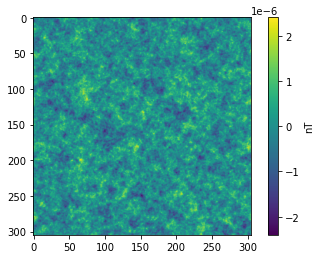

In [3]:
## Plot random fractal noise

fig = plt.figure()
ax1 = fig.add_subplot(111)
im1 = ax1.imshow(d)
fig.colorbar(im1, label='nT')

In [4]:
# initialise CurieGrid object
grid = pycurious.CurieGrid(d, xmin, xmax, ymin, ymax)

# pick the centroid
xpt = 0.5*(xmin + xmax)
ypt = 0.5*(ymin + ymax)

window_size = 304e3
subgrid = grid.subgrid(window_size, xpt, ypt)

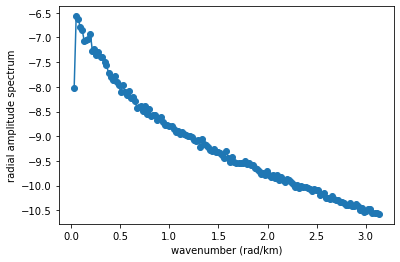

In [5]:
# compute radial power spectrum
k, Phi, sigma_Phi = grid.radial_spectrum(subgrid, taper=None, power=1)

# plot radial power spectrum
fig = plt.figure()
ax1 = fig.add_subplot(111, xlabel="wavenumber (rad/km)", ylabel="radial amplitude spectrum")
ax1.plot(k, Phi, '-o')
plt.show()

**Choice of taper**

The default taper is the hanning filter (see [`numpy.hanning`](#hanning) for more details), but other functions can be passed to taper, or simply set it to `None`. There is a significant offset in the amplitude spectrum with tapering functions, however, it is the *slope* of the spectrum with wavenumber that is most important when it comes to determining Curie depth.

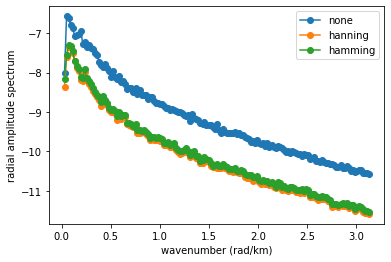

In [6]:

k1, Phi1, sigma_Phi1 = grid.radial_spectrum(subgrid, taper=None, power=1)
k2, Phi2, sigma_Phi2 = grid.radial_spectrum(subgrid, taper=np.hanning, power=1)
k3, Phi3, sigma_Phi2 = grid.radial_spectrum(subgrid, taper=np.hamming, power=1)


fig = plt.figure()
ax1 = fig.add_subplot(111, xlabel="wavenumber (rad/km)", ylabel="radial amplitude spectrum")
ax1.plot(k1, Phi1, '-o', label='none')
ax1.plot(k2, Phi2, '-o', label='hanning')
ax1.plot(k3, Phi3, '-o', label='hamming')
ax1.legend()
plt.show()